In [3]:
!pip install ultralytics nibabel opencv-python

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 25.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------- ----------------------------- 10.2/39.5 MB 53.3 MB/s eta 0:00:01
   ------------------------ --------------- 24.4/39.5 MB 61.8 MB/s eta 0:00:01
   ----------------------------------- ---- 35.1/39.5 MB 58.8 MB/s eta 0:00:01
   ---------------------------------------- 39.5/39.5 MB 53.4 MB/s eta 0:00:00

   ---------------------------------------- 0/3 [opencv-python]
   ---------------------------------------- 0/3 [opencv-python]
   -------------------------- ------------- 2/3 [ultralytics]
   -------------------------- ------------- 2/3 [ultralytics]
   -------------------------- ------------- 2/3 [ultralytics]
   -------------------------- ------------- 2/3 [ultralytics]
   -------------------------- ------------- 2/3 [ultralytics]
   --------------------------

In [4]:
import os
from pathlib import Path
import numpy as np
import nibabel as nib  # NiBabel for NIfTI file handling
import cv2             # OpenCV for image saving and processing
from ultralytics import YOLO  # Ultralytics YOLO API

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Ryan Krishna\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# Path to the patient CT data
base_dir = Path("Patient_CTs")

# Lists to store results
slice_images = []   # will hold the 2D slice arrays
slice_bboxes = []   # will hold bounding box annotations (xmin, ymin, xmax, ymax)
patient_ids   = []  # to store patient identifiers for naming

for patient_folder in base_dir.iterdir():
    if not patient_folder.is_dir():
        continue
    patient_id = patient_folder.name
    patient_ids.append(patient_id)
    
    # Define paths to CT and mask files
    ct_path = patient_folder / "ct.nii.gz"
    mask_path = patient_folder / "pubic_mask.nii.gz"
    
    # Load volumes using nibabel
    ct_img = nib.load(str(ct_path))
    mask_img = nib.load(str(mask_path))
    ct_data = ct_img.get_fdata()           # get CT volume as a numpy array:contentReference[oaicite:1]{index=1}
    mask_data = mask_img.get_fdata()       # get mask volume as numpy array
    
    # Ensure mask is binary (in case it has other values)
    mask_data = (mask_data > 0).astype(np.uint8)
    
    # Find indices of non-zero voxels in the mask
    coords = np.argwhere(mask_data == 1)
    if coords.size == 0:
        print(f"No pubic symphysis found in mask for {patient_id}, skipping.")
        continue
    
    # The mask has a blob on one slice; find that slice index (assuming axis 2 is slice index)
    # coords are of the form [x_index, y_index, z_index] for each voxel
    z_indices = coords[:, 2]
    slice_index = int(np.min(z_indices))  # the first slice where symphysis appears (should all be the same)
    
    # Extract the 2D slice from CT and mask
    ct_slice = ct_data[:, :, slice_index]
    mask_slice = mask_data[:, :, slice_index]
    
    # Compute bounding box coordinates from mask_slice
    mask_coords = np.argwhere(mask_slice == 1)
    y_coords = mask_coords[:, 0]  # axis 0 indexes rows (Y direction)
    x_coords = mask_coords[:, 1]  # axis 1 indexes columns (X direction)
    y_min, y_max = y_coords.min(), y_coords.max()
    x_min, x_max = x_coords.min(), x_coords.max()
    # Bounding box in pixel coordinates (xmin, ymin, xmax, ymax)
    bbox = (x_min, y_min, x_max, y_max)
    
    # Normalize the CT slice to 0-255 for saving as image (uint8)
    slice_img = ct_slice.astype(np.float32)
    slice_img = (slice_img - slice_img.min()) / (slice_img.max() - slice_img.min() + 1e-8)  # 0 to 1
    slice_img = (slice_img * 255).astype(np.uint8)
    
    slice_images.append(slice_img)
    slice_bboxes.append(bbox)

In [6]:
yolo_annotations = []  # list of strings for each annotation line

for bbox, img in zip(slice_bboxes, slice_images):
    x_min, y_min, x_max, y_max = bbox
    img_h, img_w = img.shape[:2]  # height, width of image
    
    # Calculate center, width, and height in pixels
    box_width  = x_max - x_min + 1
    box_height = y_max - y_min + 1
    center_x   = x_min + box_width / 2.0
    center_y   = y_min + box_height / 2.0
    
    # Normalize coordinates to [0,1]
    x_center_norm = center_x / img_w
    y_center_norm = center_y / img_h
    w_norm = box_width / img_w
    h_norm = box_height / img_h
    
    # Format as YOLO annotation string: "class x_center y_center width height"
    yolo_line = f"0 {x_center_norm:.6f} {y_center_norm:.6f} {w_norm:.6f} {h_norm:.6f}"
    yolo_annotations.append(yolo_line)

In [7]:
# Define output dataset directories
output_dir = Path("pubic_symphysis_yolo_dataset")
images_dir = output_dir / "images"
labels_dir = output_dir / "labels"
train_images_dir = images_dir / "train"
val_images_dir   = images_dir / "val"
train_labels_dir = labels_dir / "train"
val_labels_dir   = labels_dir / "val"

# Create directories if they don't exist
for d in [train_images_dir, val_images_dir, train_labels_dir, val_labels_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Determine split indices for train/val
num_images = len(slice_images)
num_val = max(1, int(0.2 * num_images))  # 20% for val (at least 1)
num_train = num_images - num_val
# Here we'll simply take the first num_train as train and the rest as val for simplicity
train_indices = list(range(num_train))
val_indices = list(range(num_train, num_images))

# Save images and labels to respective folders
for idx, (img, ann, pid) in enumerate(zip(slice_images, yolo_annotations, patient_ids)):
    # Determine if this index belongs to train or val
    if idx in train_indices:
        img_path = train_images_dir / f"{pid}.png"
        label_path = train_labels_dir / f"{pid}.txt"
    else:
        img_path = val_images_dir / f"{pid}.png"
        label_path = val_labels_dir / f"{pid}.txt"
    
    # Save image (using OpenCV imwrite; the image is single-channel grayscale)
    cv2.imwrite(str(img_path), img)
    # Save label
    with open(label_path, 'w') as f:
        f.write(ann + "\n")

In [15]:
# Initialize YOLO model (pretrained weights)
model = YOLO("yolo11n.pt")  # using a small YOLOv11 model pretrained on COCO:contentReference[oaicite:11]{index=11}

# Train the model on our dataset
results = model.train(
    data="pubic_symphysis.yaml",  # path to our dataset YAML
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,          # use GPU 0 (our RTX 4090):contentReference[oaicite:12]{index=12}
    project="yolo_runs", name="yolo11_pubic_symphysis"  # where to save training results
)

Ultralytics 8.3.147  Python-3.11.0 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=pubic_symphysis.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11_pubic_symphysis5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

train: Scanning C:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\labels\train.cache... 16 images, 0 backgrounds, 0 corrupt: 100%|██████████| 16/16 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 1499.3300.0 MB/s, size: 100.8 KB)


val: Scanning C:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\labels\val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]


Plotting labels to yolo_runs\yolo11_pubic_symphysis5\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to yolo_runs\yolo11_pubic_symphysis5
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50      1.31G      1.144      2.082       1.01          8        640: 100%|██████████| 2/2 [00:00<00:00, 13.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 28.87it/s]

                   all          4          4      0.946       0.75      0.888      0.519



50 epochs completed in 0.006 hours.
Optimizer stripped from yolo_runs\yolo11_pubic_symphysis5\weights\last.pt, 5.5MB
Optimizer stripped from yolo_runs\yolo11_pubic_symphysis5\weights\best.pt, 5.5MB

Validating yolo_runs\yolo11_pubic_symphysis5\weights\best.pt...
Ultralytics 8.3.147  Python-3.11.0 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 48.58it/s]


                   all          4          4      0.944       0.75      0.888      0.519
Speed: 0.1ms preprocess, 2.0ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to yolo_runs\yolo11_pubic_symphysis5


In [16]:
# Evaluate the trained model on the validation set
val_results = model.val()

Ultralytics 8.3.147  Python-3.11.0 torch-2.7.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1856.8317.9 MB/s, size: 100.8 KB)


val: Scanning C:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\labels\val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.21s/it]


                   all          4          4      0.944       0.75      0.888      0.519
Speed: 0.8ms preprocess, 13.0ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to yolo_runs\yolo11_pubic_symphysis52


In [17]:
# Now plot the training curves by pointing at the results.txt file
from ultralytics.utils.plotting import plot_results

plot_results("yolo_runs/yolo11_pubic_symphysis/results.txt")

In [18]:
# Load best model weights (if not already loaded)
model = YOLO("yolo_runs/yolo11_pubic_symphysis/weights/best.pt")

# Perform inference on a sample image (e.g., a validation image)
test_image_path = "pubic_symphysis_yolo_dataset/images/val/" + os.listdir(val_images_dir)[0]  # take first val image
results = model(test_image_path)  # same as model.predict(source=test_image_path)


image 1/1 c:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\images\val\Patient017.png: 640x640 (no detections), 15.1ms
Speed: 2.6ms preprocess, 15.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


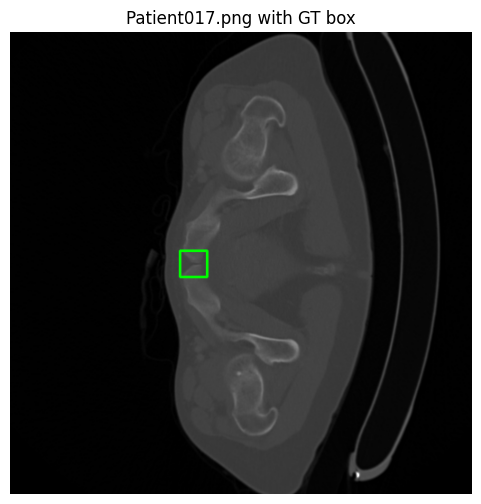

In [24]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Base dataset folder
dataset_root = Path("pubic_symphysis_yolo_dataset")

# 1. Pick a validation image filename
pid = os.listdir(dataset_root / "images" / "val")[0]  # e.g. "Patient017.png"
img_path   = dataset_root / "images" / "val" / pid
label_path = dataset_root / "labels" / "val" / pid.replace(".png", ".txt")

# 2. Read image as BGR and get its height/width
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
h, w = img_bgr.shape[:2]

# 3. Load YOLO label: "0 x_center y_center width height"
with open(label_path, 'r') as f:
    line = f.read().strip().split()
cls, x_c, y_c, bw, bh = line
x_c, y_c, bw, bh = map(float, (x_c, y_c, bw, bh))

# 4. Convert normalized coords back to pixel coords
x_center = x_c * w
y_center = y_c * h
box_w    = bw * w
box_h    = bh * h
x_min = int(x_center - box_w/2)
y_min = int(y_center - box_h/2)
x_max = int(x_center + box_w/2)
y_max = int(y_center + box_h/2)

# 5. Draw rectangle on a copy of the BGR image
vis = img_bgr.copy()
cv2.rectangle(vis, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

# 6. Show
plt.figure(figsize=(6,6))
plt.title(f"{pid} with GT box")
plt.axis("off")
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))


image 1/1 c:\Users\Ryan Krishna\Documents\Overscanning\pubic_symphysis_yolo_dataset\images\val\Patient017.png: 640x640 202 pubic_symphysiss, 21.2ms
Speed: 2.5ms preprocess, 21.2ms inference, 8.2ms postprocess per image at shape (1, 3, 640, 640)
Top detection → Conf = 0.019, Box = [348.4, 9.9, 512.0, 364.7]


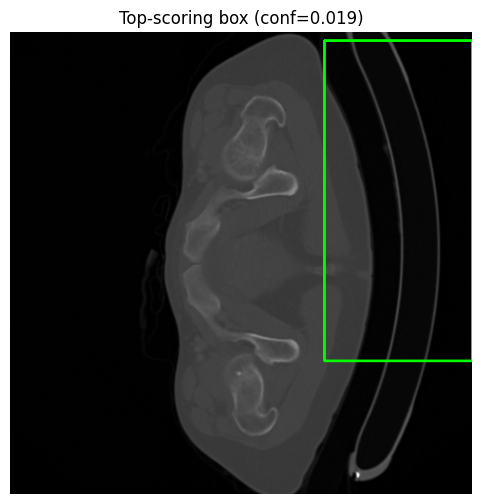

In [26]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

# 1. Load the trained model
model = YOLO("yolo_runs/yolo11_pubic_symphysis/weights/best.pt")

# 2. Pick your validation image
dataset_root = Path("pubic_symphysis_yolo_dataset")
pid = (dataset_root / "images" / "val").iterdir().__next__().name  # e.g. "Patient017.png"
img_path = dataset_root / "images" / "val" / pid

# 3. Run a very low conf‐threshold inference
results = model.predict(
    source=str(img_path),
    conf=0.01,   # keep boxes ≥ 0.01
    device=0,
    save=False
)[0]  # Results for this single image

# 4. If there are no boxes at all, this will be empty:
if len(results.boxes) == 0:
    print("No boxes even at conf≥0.01—model truly found nothing.")
else:
    # 5. Extract all (box, conf) pairs and sort descending by confidence
    boxes = results.boxes  # this is a Boxes object from ultralytics
    # Each 'box' has attributes .conf and .xyxy (tensor format)
    sorted_indices = sorted(range(len(boxes)), 
                            key=lambda i: float(boxes[i].conf), 
                            reverse=True)
    best_i = sorted_indices[0]
    best_box = boxes[best_i]
    best_conf = float(best_box.conf)
    x1, y1, x2, y2 = best_box.xyxy[0].tolist()

    print(f"Top detection → Conf = {best_conf:.3f}, Box = [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")

    # 6. Draw *only* that top box on the image
    img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    vis = img_bgr.copy()
    cv2.rectangle(vis,
                  (int(x1), int(y1)),
                  (int(x2), int(y2)),
                  (0, 255, 0), 2)
    plt.figure(figsize=(6,6))
    plt.title(f"Top‐scoring box (conf={best_conf:.3f})")
    plt.axis('off')
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))